# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import cumsum_hist, cut_scan_to_df, compute_regaxis_specs, make_regaxis, build_histogram

from tpvalidator.viz.tps import TrgPrimitivesPlotter
from tpvalidator.viz.backtracker import BackTrackerPlotter
from tpvalidator.viz.display import TriggerPrimitivesEventViewer
from typing import Literal


# Data

In [3]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'gamma']
datasets = dctl.load('data/vd/1x8x14/old_detsim', dataset_names)
gm_ws=datasets['gamma']
em_ws=datasets['eminus']


Loading eminus

Dataset 'eminus': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Workspace muminus skipped

Loading gamma

...

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Workspace mu-topo-z skipped

Workspace mu-topo-x skipped

Workspace marley skipped

Workspace radbkg skipped

# Analysis Code

In [ ]:
from scipy.optimize import curve_fit
from matplotlib.axes import Axes
from typing import Literal
from tpvalidator.detector_geometry import FDVDGeometry_1x8x14
from tpvalidator.viz.textual import format_val_err

def line(x, m, b):
    return m * x + b

def plot_fit(
    x: np.ndarray,
    y: np.ndarray,
    m: float,
    b: float,
    ax: Axes,
    m_err: float = 0,
    b_err: float = 0,
    label_x: str = '',
    label_y: str = '',
) -> None:
    """Plot data points with a linear fit and uncertainty band.

    Args:
        x: Independent variable values.
        y: Dependent variable values.
        m: Slope of the fitted line.
        b: Intercept of the fitted line.
        ax: Matplotlib axes to draw on.
        m_err: Uncertainty on the slope (used for the shaded band).
        b_err: Uncertainty on the intercept (used for the shaded band).
        label_x: Label for the x-axis.
        label_y: Label for the y-axis.
    """

    ax.scatter(x, y, s=1, alpha=0.4)
    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)

    xmin, xmax = ax.get_xlim()
    xmin, xmax = x.min(), x.max()


    lx, ly = [], []

    lx.append(xmin)
    ly.append(line(lx[0], m, b))

    lx.append(xmax)
    ly.append(line(lx[1], m, b))


    ley_down = []
    ley_down.append(line(lx[0], m-m_err, b-b_err))
    ley_down.append(line(lx[1], m-m_err, b-b_err))

    ley_up = []
    ley_up.append(line(lx[0], m+m_err, b+b_err))
    ley_up.append(line(lx[1], m+m_err, b+b_err))


    ax.plot(lx, ly, color='r')   
    plt.fill_between(lx, ley_down, ley_up, alpha=0.3)


def profile_with_spread(
    h: hist.Hist,
    profile_axis: str,
    error: Literal["sem", "std"] = "sem",
) -> hist.Hist:
    """Compute a profile histogram with spread (mean ± error) along one axis.

    Collapses `profile_axis` by computing the bin-weighted mean and spread of
    the remaining axes. The result uses ``hist.storage.Weight`` so that
    ``.value`` and ``.variance`` fields hold the mean and squared error.

    Args:
        h: Input histogram with at least one named axis.
        profile_axis: Name of the axis to profile over.
        error: Spread metric to store — ``"sem"`` (standard error of the mean)
            or ``"std"`` (standard deviation).

    Returns:
        Histogram over the non-profiled axes with mean as value and
        ``error**2`` as variance.
    """
    axes_names = [ax.name for ax in h.axes]
    assert profile_axis in axes_names, f"Axis '{profile_axis}' not found"
    assert error in ("sem", "std"), "error must be 'sem' or 'std'"

    profile_idx = axes_names.index(profile_axis)
    centers_profile = h.axes[profile_axis].centers

    counts = h.values()

    # Move profile axis to last position for broadcasting
    counts = np.moveaxis(counts, profile_idx, -1)

    N = counts.sum(axis=-1)
    mean = (counts * centers_profile).sum(axis=-1) / N
    mean2 = (counts * centers_profile**2).sum(axis=-1) / N
    std = np.sqrt(mean2 - mean**2)
    sem = std / np.sqrt(N)

    chosen_error = sem if error == "sem" else std

    # Replace empty bins with nan
    empty = N == 0
    mean = np.where(empty, np.nan, mean)
    chosen_error = np.where(empty, np.nan, chosen_error)

    # Build output with Weight storage so .value and .variance are available
    other_axes = [ax for ax in h.axes if ax.name != profile_axis]
    out = hist.Hist(*other_axes, storage=hist.storage.Weight())
    out.view(flow=False)[...] = np.stack([mean, chosen_error**2], axis=-1)

    return out

class CalibrationAnalyzer:
    """Energy calibration tool that maps per-ROP SADC sums to true kinetic energy.

    Wraps a single-particle workspace and fits a linear relationship between
    the summed ADC integral in each readout plane and the MC truth kinetic
    energy.  Both the forward (SADC → E) and inverse (E → SADC) calibrations
    are supported.
    """

    figsize=(8,6)

    def __init__(self, sp_ws:pd.DataFrame, tps_cut:str=None):
        """
        Args:
            sp_ws: Single-particle analysis workspace exposing ``.tps`` and
                ``.mctruths`` DataFrames.
            tps_cut: Optional pandas query string applied to ``.tps`` before
                computing SADC sums (e.g. ``"peak_adc > 50"``).
        """
        self._ws = sp_ws
        self._tps_cut = tps_cut
        self._calib_df = None

    
    def calib_df(self):
        """Build per-event calibration DataFrame.

        Returns:
            DataFrame indexed by ``event_uid`` with columns ``kinetic_energy``
            (MeV) and ``sadc_rop_{i}`` (summed ADC integral) for each readout
            plane.  Events missing from either source are filled with 0.
        """

        if self._calib_df is None:
            ws = self._ws
            tps = ws.tps if self._tps_cut is None else ws.tps.query(self._tps_cut)

            adc_int_sum = pd.DataFrame({f'sadc_rop_{rop}':df_rop.groupby(['event_uid']).adc_integral.sum() for rop, df_rop in tps.groupby('readout_plane_id')}).fillna(0)
            ekin = ws.mctruths[['event_uid', 'kinetic_energy']]

            # Switch to MeV
            ekin['kinetic_energy'] = ekin['kinetic_energy']*1000
            self._calib_df = ekin.join(adc_int_sum, on='event_uid', how='outer').fillna(0)

        return self._calib_df
    
    def compute_calibration(self) -> tuple:
        """Fit SADC vs kinetic energy linearly for each readout plane.

        Returns:
            DataFrame with one row per readout plane and columns
            ``m``, ``b``, ``m_err``, ``b_err`` (slope, intercept, and their
            1-sigma uncertainties from the covariance matrix).
        """
        calib_df = self.calib_df()

        rows = []
        for rop in range(FDVDGeometry_1x8x14.num_readout_planes):

            popt, pcov = curve_fit(
                line, calib_df['kinetic_energy'].values, calib_df[f'sadc_rop_{rop}'].values,
            )

            m, b = popt
            m_err, c_err = np.sqrt(np.diag(pcov))

            rows.append({
                'm': m, 'b':b, 'm_err':m_err, 'b_err':c_err
            })
        return pd.DataFrame(rows)

    def plot_calibration(self, rop:int, figsize=figsize, **kwargs):
        """Plot SADC vs kinetic energy with a linear fit for one readout plane.

        Args:
            rop: Readout plane index.
            figsize: Figure size passed to ``plt.subplots``.
            **kwargs: Additional keyword arguments forwarded to ``plt.subplots``.

        Returns:
            The matplotlib Figure.
        """
        cal_df = self.calib_df()
        cal_fit = self.compute_calibration()

        fig, ax = plt.subplots(1,1, figsize=figsize, **kwargs)
        plot_fit(cal_df.kinetic_energy, cal_df[f'sadc_rop_{rop}'], label_x='$E_{kin}$ [MeV]', label_y='SADC', ax=ax, **(cal_fit.iloc[rop]))
        ax.set_title(f'adc_integral - Energy calibration (plane {rop})')

        slope, intercept, slope_err, intercept_err = cal_fit.iloc[rop]

        # Stat box
        stats_text = "\n".join([
            r"$\bf{Linear\ Fit}$",
            f"m = {format_val_err(slope, slope_err)} adc/MeV",
            f"b = {format_val_err(intercept, intercept_err)} adc",
            # f"R²        = {r2:.4f}",
            # f"Std res   = {residuals.std():.3f}",
            # f"N         = {n}",
        ])

        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8),
                # fontfamily="monospace"
                )

        fig.tight_layout()
        return fig
    
    def plot_calibration_spread(self, rop:int, ke_binsize:int=5, sadc_binsize:int=2000, cmap:str='viridis', figsize=figsize):
        """Plot 2D SADC vs energy histogram with a profile and relative-spread panel.

        The top panel shows a 2D histogram with the mean SADC profile overlaid.
        The bottom panel shows the relative spread σ_SADC / SADC as a function
        of kinetic energy.

        Args:
            rop: Readout plane index.
            ke_binsize: Bin width for the kinetic-energy axis (MeV).
            sadc_binsize: Bin width for the SADC axis (ADC counts).
            cmap: Colormap name for the 2D histogram.
            figsize: Figure size.
        """
        cal_df = self.calib_df()
    
        ke_axis = make_regaxis(cal_df, 'kinetic_energy', ke_binsize, label='$E_{kin}$ [MeV]')
        sadc_axis = make_regaxis(cal_df, f'sadc_rop_{rop}', sadc_binsize, label='SADC')

        h = build_histogram(cal_df, [ke_axis, sadc_axis])

        import copy

        h_plot = copy.deepcopy(h)
        vals = h_plot.view()
        h_plot.view()[vals == 0] = np.nan  # mplhep treats NaN as masked


        fig, axes = plt.subplot_mosaic(
            [["top", "cbar"],
            ["bot", "."  ]],
            figsize=figsize,
            gridspec_kw={"width_ratios": [20, 1], "height_ratios": [4, 1],
                        "hspace": 0.05, "wspace": 0.1},
        )
        ax_top = axes["top"]
        ax_bot = axes["bot"]
        cax    = axes["cbar"]

        hep.hist2dplot(h_plot, ax=ax_top, cbar=False, cmap=cmap)

        mesh = ax_top.collections[0]             # grab the QuadMesh for the colorbar
        plt.colorbar(mesh, cax=cax, label="Counts")

        h_prof = profile_with_spread(h, f'sadc_rop_{rop}', error='std')

        hep.histplot(h_prof, histtype='errorbar', ax=ax_top, color="crimson")
        ax_top.grid()
        # Hide ticks AND labels
        ax_top.tick_params(bottom=False, labelbottom=False)
        x_label = ax_top.get_xlabel()

        ax_top.set_xlabel(None)


        ax_bot.axhline(1, color="gray", linestyle="--", linewidth=0.8)

        ax_bot.plot(h_prof.axes['kinetic_energy'].centers, np.sqrt(h_prof.variances())/h_prof.values(), color="crimson")
        ax_bot.grid()
        ax_bot.set_xlabel(x_label)
        ax_bot.set_ylabel(r'$\sigma_{SADC}/SACD$')


        ax_top.set_title(f"SADC spread as a function of energy (plane {rop})")
        # fig.tight_layout()

    def compute_calibration_inv(self) -> tuple:
        """Fit kinetic energy vs SADC linearly for each readout plane (inverse calibration).

        Returns:
            DataFrame with one row per readout plane and columns
            ``m``, ``b``, ``m_err``, ``b_err`` (slope, intercept, and their
            1-sigma uncertainties from the covariance matrix).
        """
        calib_df = self.calib_df()

        rows = []
        for rop in range(FDVDGeometry_1x8x14.num_readout_planes):

            popt, pcov = curve_fit(
                line, calib_df[f'sadc_rop_{rop}'].values, calib_df['kinetic_energy'].values
            )

            m, b = popt
            m_err, c_err = np.sqrt(np.diag(pcov))

            rows.append({
                'm': m, 'b':b, 'm_err':m_err, 'b_err':c_err
            })
        return pd.DataFrame(rows)

    def plot_calibration_inv(self, rop:int, figsize=figsize, **kwargs):
        """Plot kinetic energy vs SADC (inverse calibration) with a linear fit.

        Args:
            rop: Readout plane index.
            figsize: Figure size passed to ``plt.subplots``.
            **kwargs: Additional keyword arguments forwarded to ``plt.subplots``.

        Returns:
            The matplotlib Figure.
        """
        cal_df = self.calib_df()
        cal_inv_fit = self.compute_calibration_inv()

        fig, ax = plt.subplots(1,1, figsize=figsize, **kwargs)
        plot_fit(cal_df[f'sadc_rop_{rop}'], cal_df.kinetic_energy, label_y='$E_{kin}$ [MeV]', label_x='SADC', ax=ax, **(cal_inv_fit.iloc[rop]))
        ax.set_title(f'adc_integral - Energy calibration (plane {rop})')

        slope, intercept, slope_err, intercept_err = cal_inv_fit.iloc[rop]

        # Stat box
        stats_text = "\n".join([
            r"$\bf{Linear\ Fit}$",
            f"m = {format_val_err(slope, slope_err)} adc/MeV",
            f"b = {format_val_err(intercept, intercept_err)} adc",
            # f"R²        = {r2:.4f}",
            # f"Std res   = {residuals.std():.3f}",
            # f"N         = {n}",
        ])

        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8),
                # fontfamily="monospace"
                )

        fig.tight_layout()
        return fig

# Energy Calibration

This noteboosk calculates the TP energy calibration for Simple Threshold TPs, using the `adc_integral` sum over particle gun events: single electrons or single gammas

## E-minus sample

In [23]:
em_ca = CalibrationAnalyzer(em_ws)

For each event in the e- dataset, the sum of `adc_integral` is calculated per plane, and associated to the event energy.

The calibration is calculated as a linear fit to `sum_adc` and `kinetic_energy`

In [24]:
em_calib_df = em_ca.calib_df()
display(em_calib_df)

em_cal = em_ca.compute_calibration()
display(em_cal)

em_cal_inv = em_ca.compute_calibration_inv()
display(em_cal_inv)


,,event_uid,kinetic_energy,sadc_rop_0,sadc_rop_1,sadc_rop_2
entry,subentry,,,,,
0,0,20000011000001,22.218892,17519.0,19484.0,54957.0
1,0,20000011000002,10.951618,52.0,0.0,0.0
2,0,20000011000003,39.608298,24294.0,27772.0,90792.0
3,0,20000011000004,18.916121,16342.0,16799.0,30675.0
4,0,20000011000005,48.403791,62177.0,71131.0,129034.0
...,...,...,...,...,...,...
995,0,20000011000996,1.550719,0.0,0.0,0.0
996,0,20000011000997,2.241050,1837.0,2205.0,3505.0
997,0,20000011000998,16.636964,22288.0,14449.0,47616.0


,m,b,m_err,b_err
0,953.685913,-2102.909602,17.908520,1014.504841
1,983.945464,-2072.770285,19.932344,1129.153017
2,2448.990638,-6860.747030,25.783713,1460.628857


,m,b,m_err,b_err
0,0.000776,14.323588,0.000015,0.796913
1,0.000721,15.661730,0.000015,0.831665
2,0.000368,7.379101,0.000004,0.522309


# Results - e-minus

In [29]:
from IPython.display import Markdown, display
display(Markdown(f"""
| Plane | Slope | Slope error | Intercept | Intercept error |
|-----------|-------|---|---|---|
"""+
'\n'.join(
    f'| {p}     | {em_cal['m'][p]:.2f}  | {em_cal['m_err'][p]:.2f} | {em_cal['b'][p]:.2f}  | {em_cal['b_err'][p]:.2f} '
    for p in range(FDVDGeometry_1x8x14.num_readout_planes)
)
))


| Plane | Slope | Slope error | Intercept | Intercept error |
|-----------|-------|---|---|---|
| 0     | 953.69  | 17.91 | -2102.91  | 1014.50 
| 1     | 983.95  | 19.93 | -2072.77  | 1129.15 
| 2     | 2448.99  | 25.78 | -6860.75  | 1460.63 

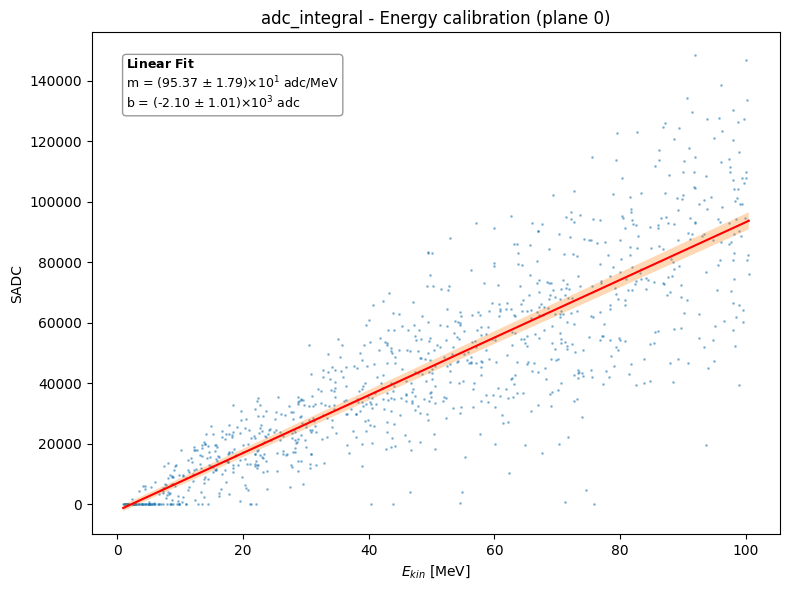

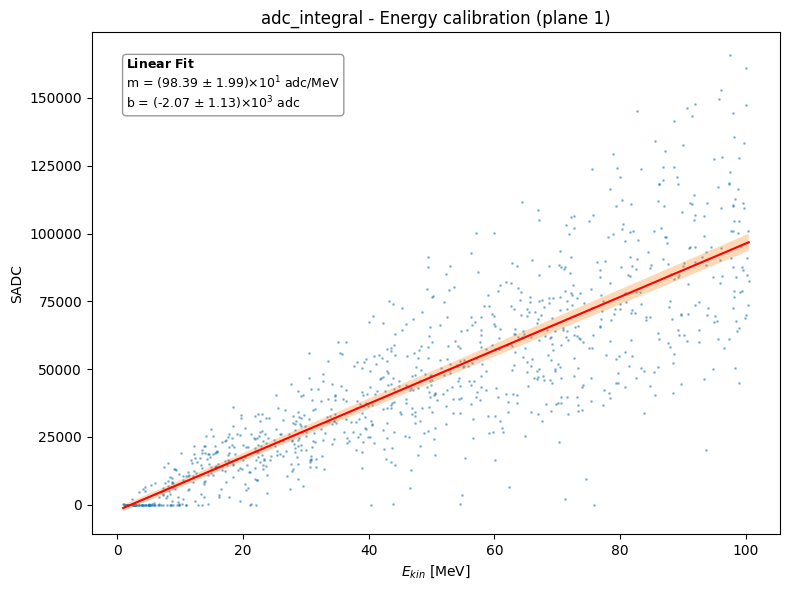

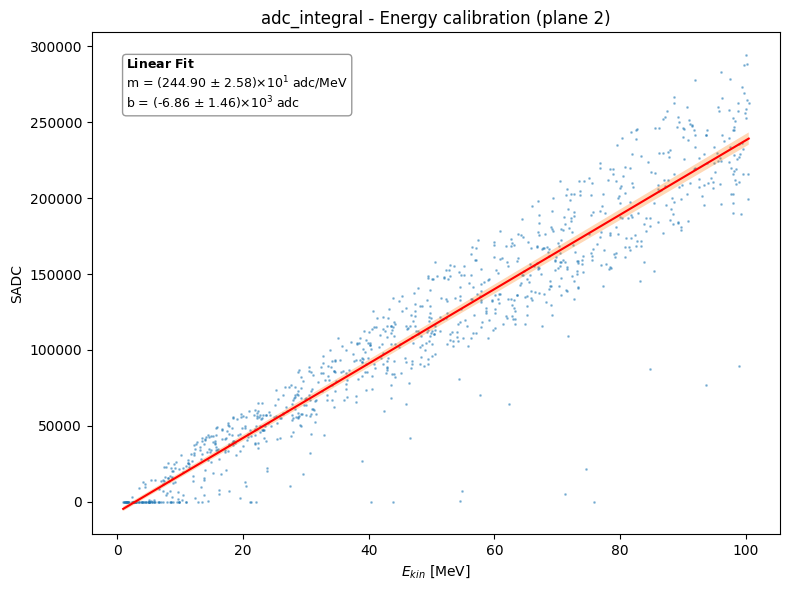

In [8]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    fig = em_ca.plot_calibration(rop)

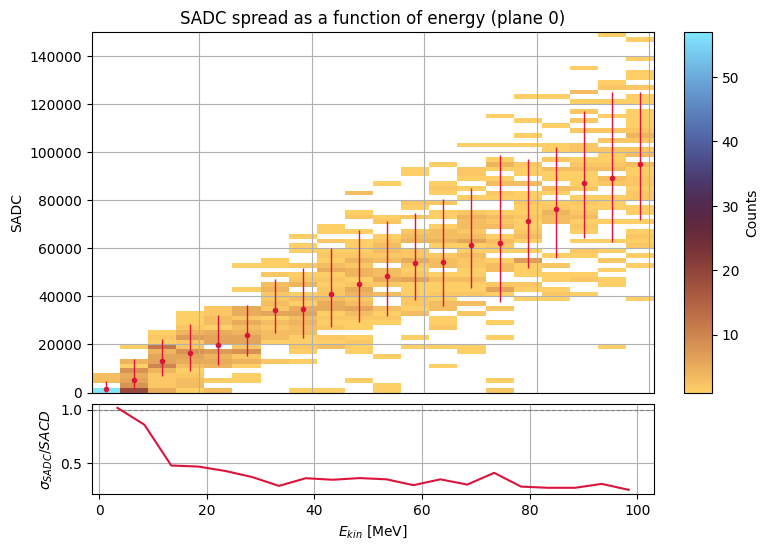

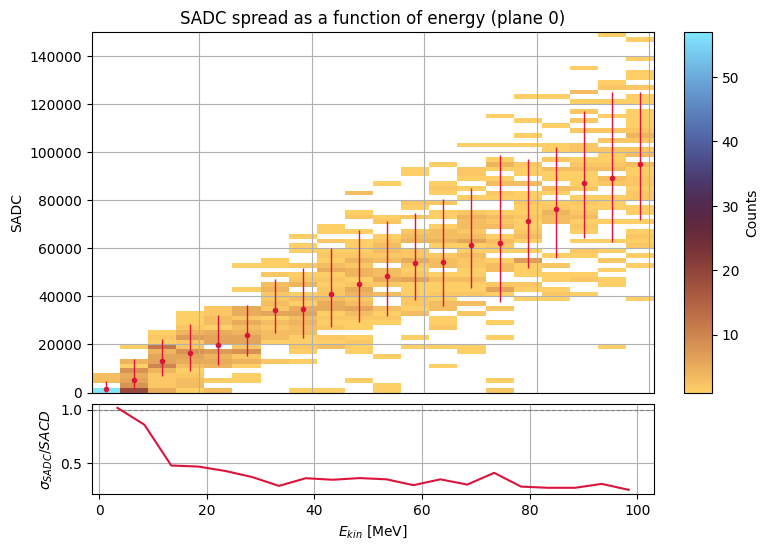

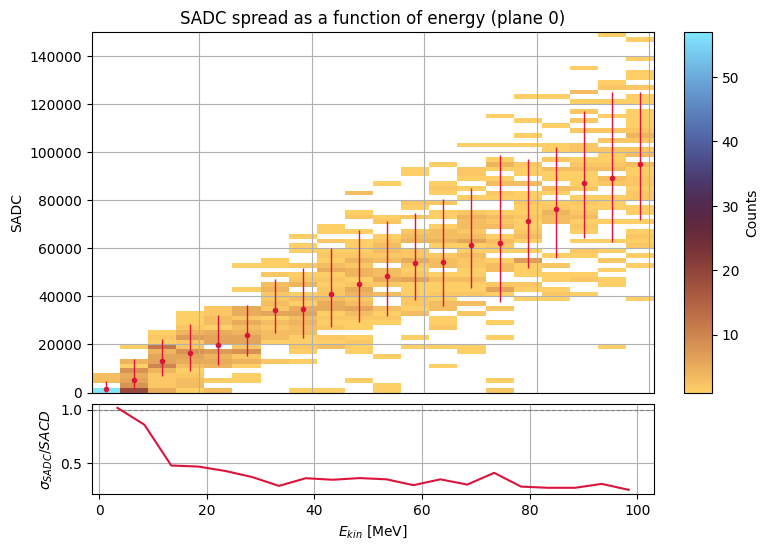

In [9]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    em_ca.plot_calibration_spread(0, cmap='managua')

## Gammas

In [10]:
gm_ca = CalibrationAnalyzer(gm_ws)

In [11]:
gm_calib_df = gm_ca.calib_df()
display(gm_calib_df)

gm_cal = gm_ca.compute_calibration()
display(gm_cal)

,,event_uid,kinetic_energy,sadc_rop_0,sadc_rop_1,sadc_rop_2
entry,subentry,,,,,
0,0,20000011000001,27.549494,38503.0,42826.0,83973.0
1,0,20000011000002,51.654924,68056.0,71965.0,139140.0
2,0,20000011000003,9.749944,47.0,0.0,47.0
3,0,20000011000004,94.542475,87933.0,73881.0,205611.0
4,0,20000011000005,72.085393,58637.0,68854.0,199349.0
...,...,...,...,...,...,...
995,0,20000011000996,84.439416,56835.0,54502.0,171302.0
996,0,20000011000997,74.042727,56686.0,44397.0,146204.0
997,0,20000011000998,32.023091,22459.0,25100.0,64064.0


,m,b,m_err,b_err
0,889.057959,330.104335,18.986553,1114.423145
1,943.564034,33.165532,21.442671,1258.588195
2,2369.855329,-2379.247765,30.800404,1807.841065


# Results - gamma

In [12]:
from IPython.display import Markdown, display
display(Markdown(f"""
| Plane | Slope | Slope error | Intercept | Intercept error |
|-----------|-------|---|---|---|
"""+
'\n'.join(
    f'| {p}     | **{gm_cal['m'][p]:.2f}**  | **{gm_cal['m_err'][p]:.2f}** | **{gm_cal['b'][p]:.2f}**  | **{gm_cal['b_err'][p]:.2f}**'
    for p in range(FDVDGeometry_1x8x14.num_readout_planes)
)
))


| Plane | Slope | Slope error | Intercept | Intercept error |
|-----------|-------|---|---|---|
| 0     | **889.06**  | **18.99** | **330.10**  | **1114.42**
| 1     | **943.56**  | **21.44** | **33.17**  | **1258.59**
| 2     | **2369.86**  | **30.80** | **-2379.25**  | **1807.84**

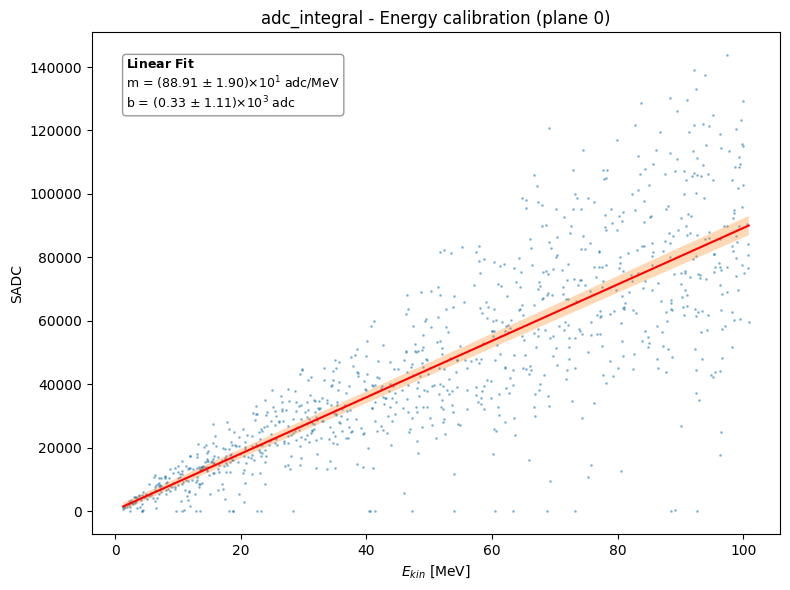

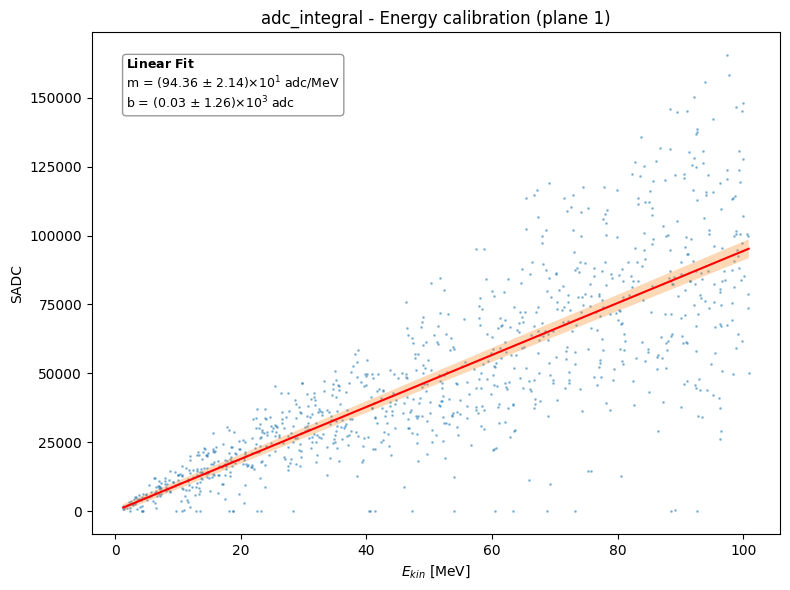

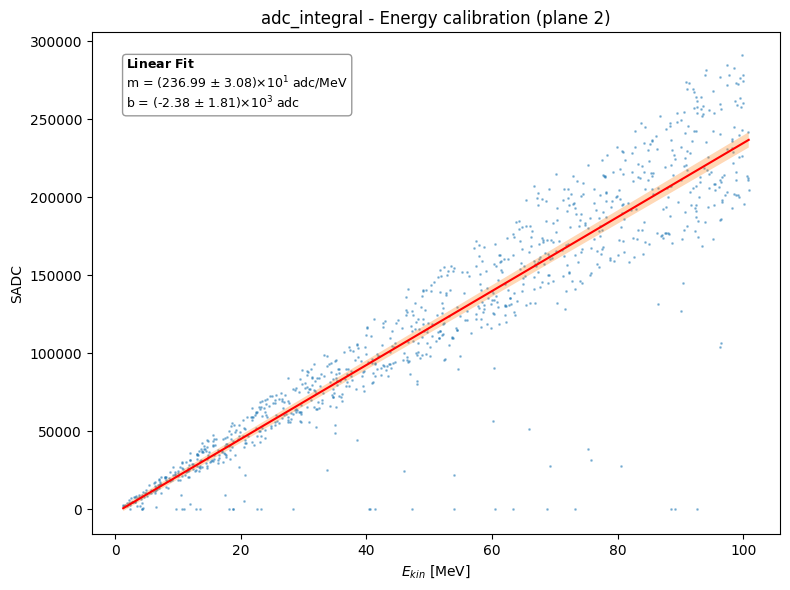

In [13]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    fig = gm_ca.plot_calibration(rop)

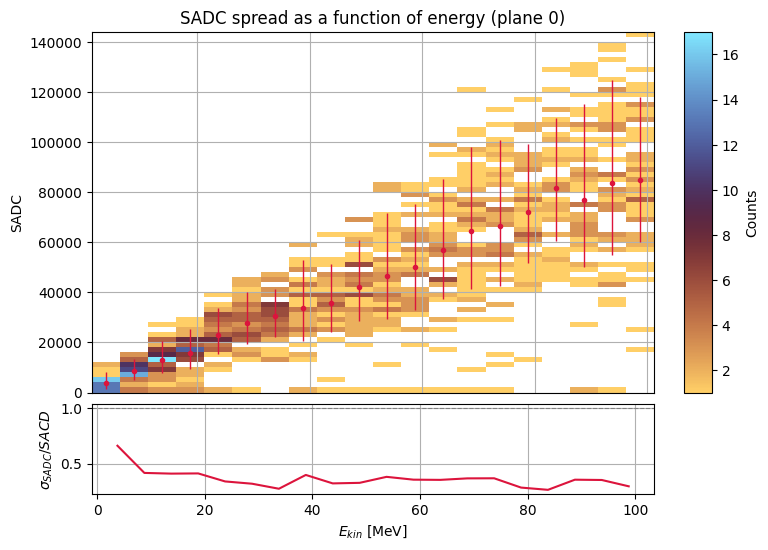

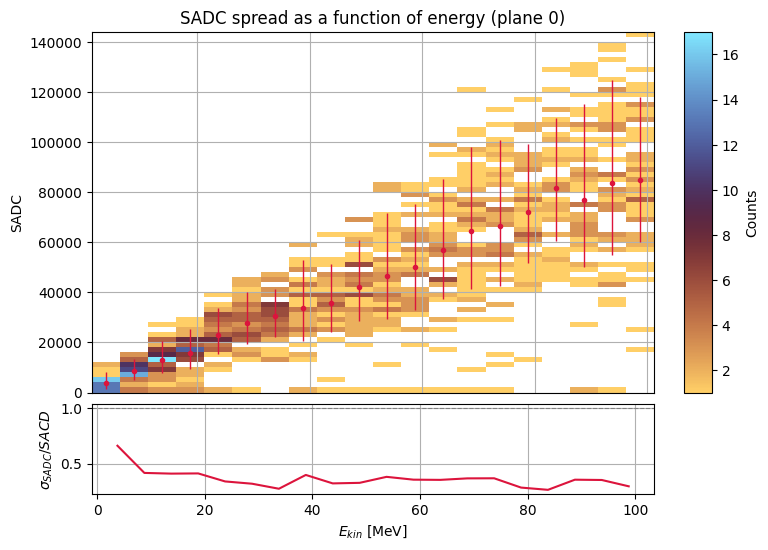

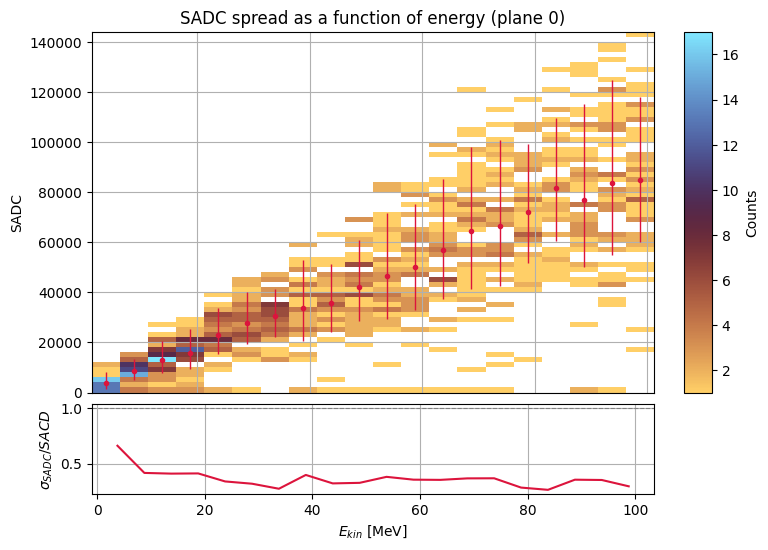

In [14]:
for rop in range(FDVDGeometry_1x8x14.num_readout_planes):
    gm_ca.plot_calibration_spread(0, cmap='managua')